# ViT (Vision Transformer) Training on Food-101

This notebook trains a Vision Transformer (ViT) on the Food-101 dataset from Hugging Face.

**Model:** ViT-Base/16 (ImageNet pretrained)  
**Dataset:** Food-101 (101 classes, ~101K images)

## 1. Setup and Imports

In [1]:
# Install dependencies (run once)
# !pip install torch torchvision timm pytorch-lightning datasets rich

In [2]:
import torch
import pytorch_lightning as pl
from datasets import load_dataset
import matplotlib.pyplot as plt

# Import shared utilities
from utils import (
    Config, set_seed, get_train_transforms, get_val_transforms,
    HFImageDataset, FoodClassifier, create_dataloaders,
    get_trainer_callbacks, save_class_mapping
)

# Set seed for reproducibility
set_seed(Config.SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti


## 2. Load Food-101 Dataset

In [3]:
# Load dataset from Hugging Face
print("Loading Food-101 dataset...")
dataset = load_dataset("ethz/food101")

print(f"Train samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")

Loading Food-101 dataset...
Train samples: 75750
Validation samples: 25250


In [4]:
# Extract class information
class_names = dataset["train"].features["label"].names
num_classes = len(class_names)

id2label = {i: name for i, name in enumerate(class_names)}
label2id = {name: i for i, name in id2label.items()}

print(f"Number of classes: {num_classes}")
print(f"\nFirst 10 classes: {class_names[:10]}")

Number of classes: 101

First 10 classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


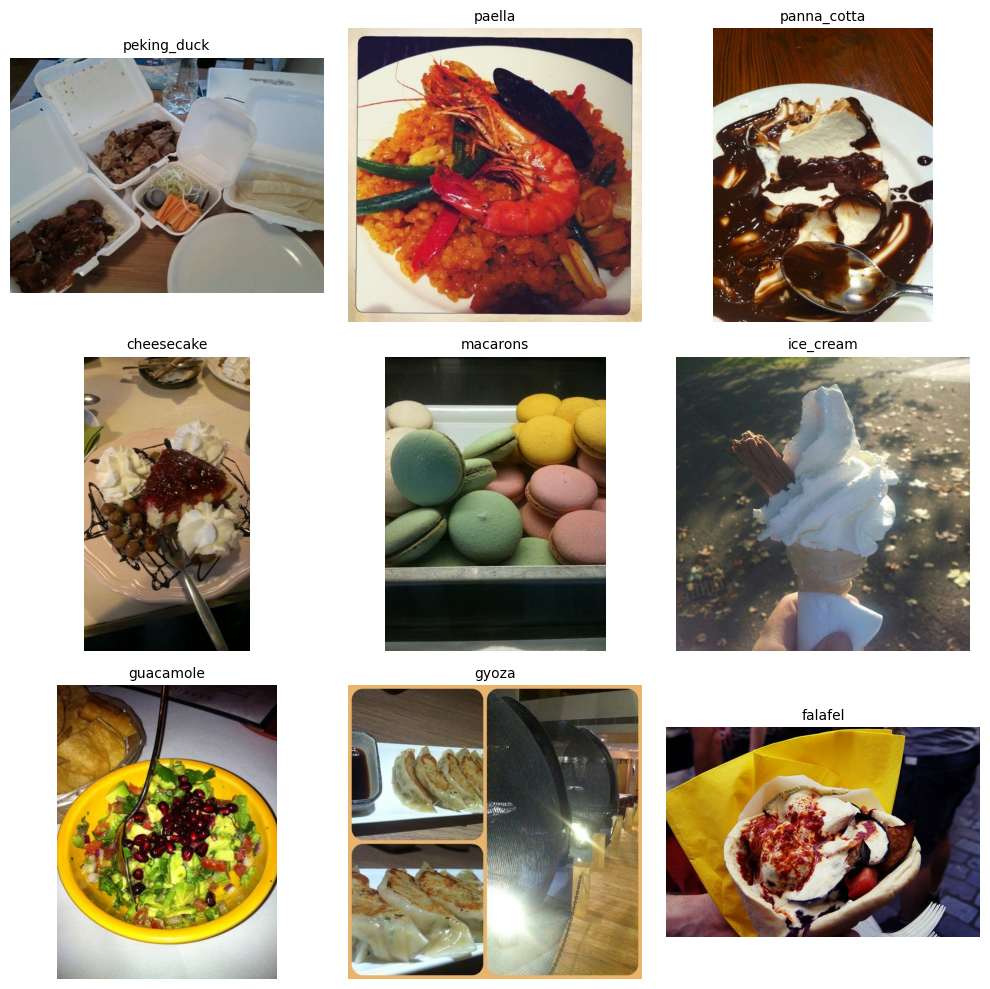

In [5]:
# Visualize sample images
sample = dataset["train"].shuffle(seed=42).select(range(9))

plt.figure(figsize=(10, 10))
for i, item in enumerate(sample):
    plt.subplot(3, 3, i+1)
    plt.imshow(item["image"])
    plt.title(id2label[item["label"]], fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Create Datasets and DataLoaders

In [6]:
# Create datasets with transforms
train_ds = HFImageDataset(dataset["train"], transform=get_train_transforms())
val_ds = HFImageDataset(dataset["validation"], transform=get_val_transforms())

# Create dataloaders
train_dl, val_dl = create_dataloaders(train_ds, val_ds)

print(f"Train batches: {len(train_dl)}")
print(f"Val batches: {len(val_dl)}")

Train batches: 1184
Val batches: 395


In [7]:
# Verify batch shape
batch = next(iter(train_dl))
images, labels = batch
print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

Batch images shape: torch.Size([64, 3, 224, 224])
Batch labels shape: torch.Size([64])


## 4. Initialize ViT Model

In [8]:
# Model configuration
MODEL_NAME = Config.MODELS['vit']  # vit_base_patch16_224
EXPERIMENT_NAME = f"food101_{MODEL_NAME.replace('/', '_')}"

print(f"Model: {MODEL_NAME}")
print(f"Number of classes: {num_classes}")
print(f"Learning rate: {Config.LEARNING_RATE}")
print(f"Max epochs: {Config.MAX_EPOCHS}")

Model: vit_base_patch16_224
Number of classes: 101
Learning rate: 0.0001
Max epochs: 10


In [9]:
# Create model
model = FoodClassifier(
    backbone_name=MODEL_NAME,
    num_classes=num_classes,
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY,
)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 85,876,325
Trainable parameters: 85,876,325


## 5. Training

In [10]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

# Callbacks
checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{EXPERIMENT_NAME}",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="{epoch:02d}-{val_acc:.4f}",
)

early_stop_cb = EarlyStopping(
    monitor="val_acc",
    mode="max",
    patience=Config.EARLY_STOP_PATIENCE,
    verbose=True,
)

# Logger
logger = TensorBoardLogger("logs", name=EXPERIMENT_NAME)

# Trainer
trainer = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[checkpoint_cb, early_stop_cb],
    logger=logger,
    precision="16-mixed" if torch.cuda.is_available() else 32,
    log_every_n_steps=50,
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [11]:
# Train the model
print(f"Starting training for {EXPERIMENT_NAME}...")
trainer.fit(model, train_dl, val_dl)

You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting training for food101_vit_base_patch16_224...


c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ VisionTransformer │ 85.9 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 85.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.9 M                                                                                               
Total estimated model params size (MB): 343                                                                        
Modules in train mode: 277                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Metric val_acc improved by 0.002 >= min_delta = 0.0. New best score: 0.853


Metric val_acc improved by 0.015 >= min_delta = 0.0. New best score: 0.868


Metric val_acc improved by 0.013 >= min_delta = 0.0. New best score: 0.882


Metric val_acc improved by 0.002 >= min_delta = 0.0. New best score: 0.883


Metric val_acc improved by 0.005 >= min_delta = 0.0. New best score: 0.888
`Trainer.fit` stopped: `max_epochs=10` reached.


In [12]:
# Print best checkpoint path
print(f"\nBest model checkpoint: {checkpoint_cb.best_model_path}")
print(f"Best validation accuracy: {checkpoint_cb.best_model_score:.4f}")


Best model checkpoint: C:\Users\royli\vscode projects\food image classification\food_classifier_project\checkpoints\food101_vit_base_patch16_224\epoch=09-val_acc=0.8884.ckpt
Best validation accuracy: 0.8884


## 6. Evaluation

In [13]:
# Load best model
best_model = FoodClassifier.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    backbone_name=MODEL_NAME,
    num_classes=num_classes,
)
best_model.eval()

# Validate
results = trainer.validate(best_model, val_dl)
print(f"\nFinal validation results: {results}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8883564472198486     │
│         val_loss          │    0.5016904473304749     │
│       val_macro_acc       │    0.8883565068244934     │
└───────────────────────────┴───────────────────────────┘


Final validation results: [{'val_loss': 0.5016904473304749, 'val_acc': 0.8883564472198486, 'val_macro_acc': 0.8883565068244934}]


In [14]:
# Save class mapping for inference
save_class_mapping(id2label, f"checkpoints/{EXPERIMENT_NAME}/id2label.json")
print(f"Class mapping saved to checkpoints/{EXPERIMENT_NAME}/id2label.json")

Class mapping saved to checkpoints/food101_vit_base_patch16_224/id2label.json


## 7. Quick Inference Test

True label: beignets
Predicted: beignets
Confidence: 100.00%


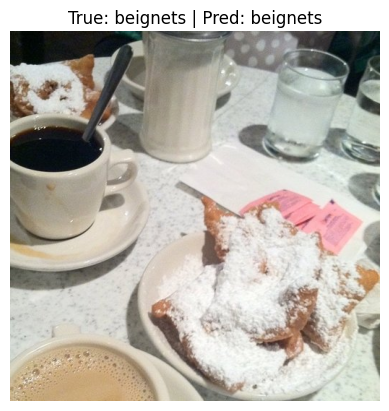

In [15]:
# Test inference on a sample
device = "cuda" if torch.cuda.is_available() else "cpu"
best_model.to(device)

# Get a sample from validation set
sample_item = dataset["validation"][0]
sample_img = sample_item["image"]
true_label = sample_item["label"]

# Preprocess
val_tfms = get_val_transforms()
if sample_img.mode != "RGB":
    sample_img = sample_img.convert("RGB")
x = val_tfms(sample_img).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    logits = best_model(x)
    pred = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1).max().item()

print(f"True label: {id2label[true_label]}")
print(f"Predicted: {id2label[pred]}")
print(f"Confidence: {confidence:.2%}")

# Show image
plt.imshow(sample_item["image"])
plt.title(f"True: {id2label[true_label]} | Pred: {id2label[pred]}")
plt.axis("off")
plt.show()

## 8. Export to ONNX (Optional)

In [16]:
# Export to ONNX for deployment
best_model.cpu()
best_model.eval()

dummy_input = torch.randn(1, 3, Config.IMAGE_SIZE, Config.IMAGE_SIZE)
onnx_path = f"checkpoints/{EXPERIMENT_NAME}/model.onnx"

torch.onnx.export(
    best_model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"},
    },
)

print(f"ONNX model saved to {onnx_path}")

C:\Users\royli\AppData\Local\Temp\ipykernel_30748\1814813311.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\torch\__init__.py:2174: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace m

ONNX model saved to checkpoints/food101_vit_base_patch16_224/model.onnx


---
## Summary

| Metric | Value |
|--------|-------|
| Model | ViT-Base/16 |
| Dataset | Food-101 |
| Best Val Acc | See above |
| Parameters | ~86M |